# Feature Engineering

what do we actually hand to the model?

Raw text has no natural numerical form, there's no inherent distance between "terrible" and "excellent" the way there is between 2 and 10. so we need to turn them to numbers with meaning.

There're two layers. First, a linguistic analysis: looking at which words and phrases actually separate positive from negative reviews in our cleaned data, grounding every subsequent decision in evidence, not assumption. Then the transformation: converting text into TF-IDF vectors, validating those vectors geometrically as in the similarity between them.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

## Environment Setup

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import show_top_ngrams_by_class, add_basic_meta_features, plot_dimensionality_reduction, save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Loading the Cleaned Training Data

We pick up exactly where preprocessing left off: the balanced, cleaned training set with `review_content_cleaned` ready to analyse.

In [3]:
processed_train = pd.read_csv(r'data/processed/processed_train.csv', dtype=str, quoting=0)
processed_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count,review_content_cleaned,review_title_cleaned
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...,great camra
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...,not great
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...,inaccurate disappointing
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...,equus 3340
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...,awesome sheet


In [4]:
processed_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 79972 entries, 0 to 79971
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   review_target              79972 non-null  str  
 1   review_title               79972 non-null  str  
 2   review_content             79972 non-null  str  
 3   review_content_char_count  79972 non-null  str  
 4   review_content_word_count  79972 non-null  str  
 5   review_content_cleaned     79972 non-null  str  
 6   review_title_cleaned       79607 non-null  str  
dtypes: str(7)
memory usage: 4.3 MB


## Class-Conditional N-gram Analysis, Finding What Actually Separates the Two Classes

We split by sentiment class and look at what's distinctive to each. A word like "book" might appear frequently in both positive and negative reviews, it tells the model almost nothing. What we're hunting for are terms that appear heavily in one class and barely in the other, those are the real discriminating features.

In [5]:
feat_eng_train = processed_train.copy()

Top unigrams for class 1 and 2 of cleaned review

--- Top unigrams for class 1 ---
[('book', np.int64(22267)), ('like', np.int64(11613)), ('time', np.int64(9543)), ('good', np.int64(8317)), ('movie', np.int64(7780)), ('read', np.int64(6545)), ('product', np.int64(6364)), ('work', np.int64(6202)), ('really', np.int64(5892)), ('buy', np.int64(5447)), ('make', np.int64(5187)), ('money', np.int64(5070)), ('better', np.int64(5002)), ('bought', np.int64(4836)), ('great', np.int64(4585))]



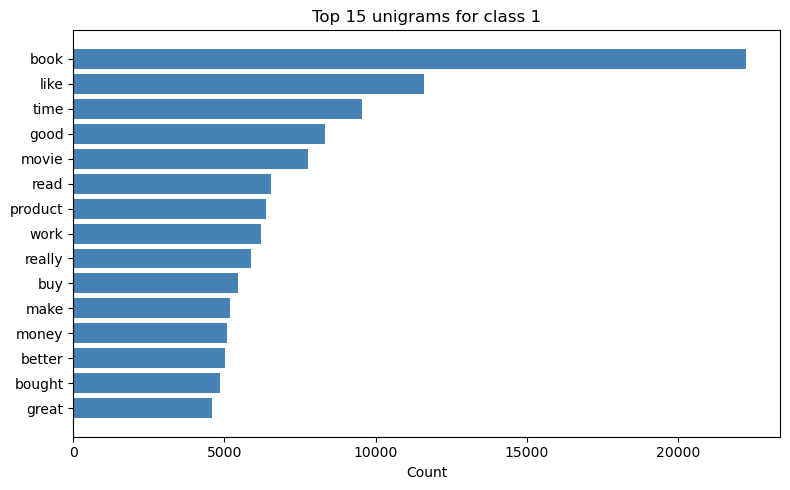

--- Top unigrams for class 2 ---
[('book', np.int64(23178)), ('great', np.int64(13512)), ('like', np.int64(10799)), ('good', np.int64(10496)), ('time', np.int64(8353)), ('read', np.int64(8136)), ('love', np.int64(7968)), ('movie', np.int64(6466)), ('really', np.int64(6304)), ('album', np.int64(5557)), ('cd', np.int64(5496)), ('work', np.int64(5403)), ('year', np.int64(5287)), ('make', np.int64(5260)), ('best', np.int64(5110))]



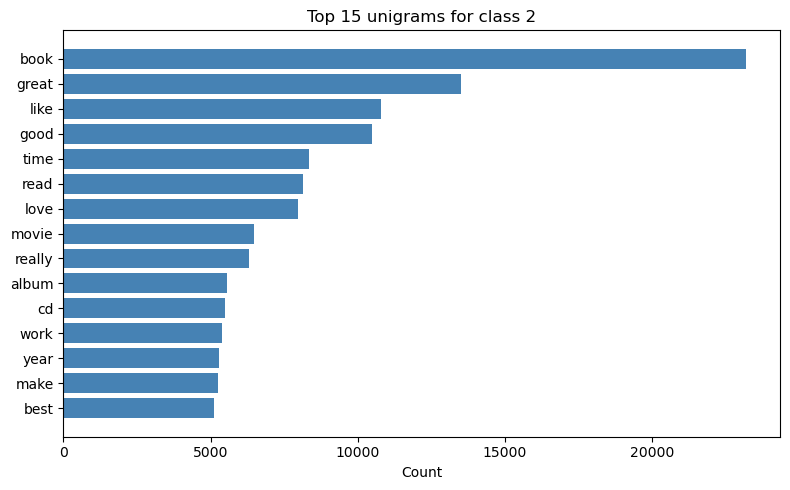

{'1': {(1, 1): [('book', np.int64(22267)),
   ('like', np.int64(11613)),
   ('time', np.int64(9543)),
   ('good', np.int64(8317)),
   ('movie', np.int64(7780)),
   ('read', np.int64(6545)),
   ('product', np.int64(6364)),
   ('work', np.int64(6202)),
   ('really', np.int64(5892)),
   ('buy', np.int64(5447)),
   ('make', np.int64(5187)),
   ('money', np.int64(5070)),
   ('better', np.int64(5002)),
   ('bought', np.int64(4836)),
   ('great', np.int64(4585))]},
 '2': {(1, 1): [('book', np.int64(23178)),
   ('great', np.int64(13512)),
   ('like', np.int64(10799)),
   ('good', np.int64(10496)),
   ('time', np.int64(8353)),
   ('read', np.int64(8136)),
   ('love', np.int64(7968)),
   ('movie', np.int64(6466)),
   ('really', np.int64(6304)),
   ('album', np.int64(5557)),
   ('cd', np.int64(5496)),
   ('work', np.int64(5403)),
   ('year', np.int64(5287)),
   ('make', np.int64(5260)),
   ('best', np.int64(5110))]}}

In [6]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_content_cleaned', ngram_ranges=(1, 1), top_k=15)


## What the Unigrams Tell Us

The class-conditional unigram plot confirms something important: the two vocabularies are genuinely distinct but not representative enough as it only holds one word as the -ve class cantain its own distinctive words plus some (more than some) of the +ve class words.

Top bigrams for class 1 and 2 of cleaned review

--- Top bigrams for class 1 ---
[('waste money', np.int64(1455)), ('read book', np.int64(983)), ('waste time', np.int64(928)), ('year old', np.int64(898)), ('look like', np.int64(688)), ('save money', np.int64(655)), ('sound like', np.int64(636)), ('book read', np.int64(618)), ('year ago', np.int64(497)), ('customer service', np.int64(464)), ('reading book', np.int64(425)), ('read review', np.int64(378))]



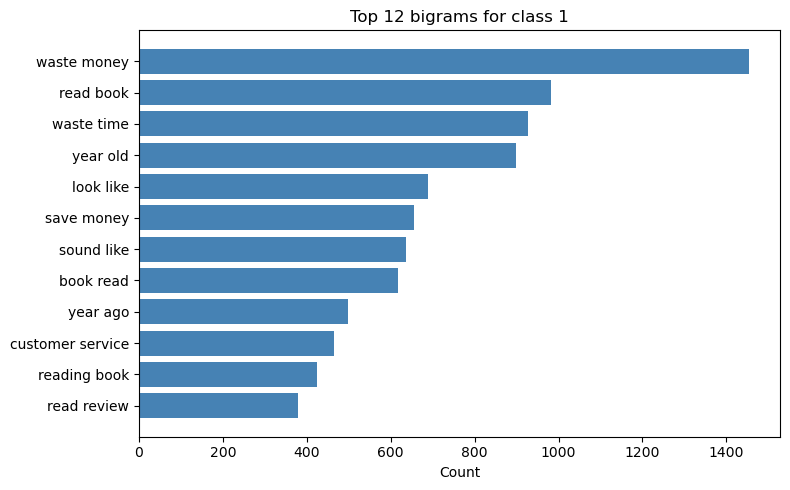

--- Top bigrams for class 2 ---
[('read book', np.int64(1421)), ('highly recommend', np.int64(1114)), ('year old', np.int64(1071)), ('book read', np.int64(914)), ('year ago', np.int64(690)), ('recommend book', np.int64(604)), ('great book', np.int64(558)), ('work great', np.int64(554)), ('long time', np.int64(534)), ('reading book', np.int64(511)), ('book great', np.int64(487)), ('highly recommended', np.int64(473))]



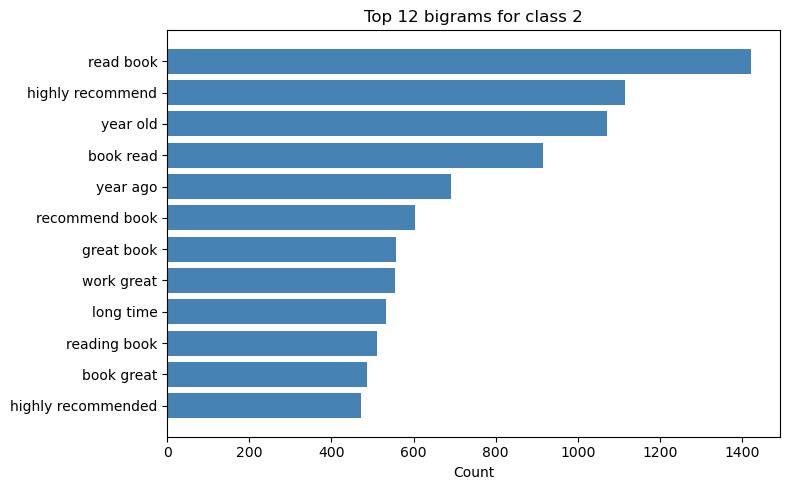

{'1': {(2, 2): [('waste money', np.int64(1455)),
   ('read book', np.int64(983)),
   ('waste time', np.int64(928)),
   ('year old', np.int64(898)),
   ('look like', np.int64(688)),
   ('save money', np.int64(655)),
   ('sound like', np.int64(636)),
   ('book read', np.int64(618)),
   ('year ago', np.int64(497)),
   ('customer service', np.int64(464)),
   ('reading book', np.int64(425)),
   ('read review', np.int64(378))]},
 '2': {(2, 2): [('read book', np.int64(1421)),
   ('highly recommend', np.int64(1114)),
   ('year old', np.int64(1071)),
   ('book read', np.int64(914)),
   ('year ago', np.int64(690)),
   ('recommend book', np.int64(604)),
   ('great book', np.int64(558)),
   ('work great', np.int64(554)),
   ('long time', np.int64(534)),
   ('reading book', np.int64(511)),
   ('book great', np.int64(487)),
   ('highly recommended', np.int64(473))]}}

In [7]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_content_cleaned', ngram_ranges=(2, 2), top_k=12)

## What the Bigrams Tell Us

The bigram separation is sharper than the unigram separation. Phrases like highly recommend and great product appear almost exclusively in positive reviews, while waste money and poor qualit* are reliably negative and as a note, neither of those signals would survive if we treated not, poor, or waste as stopwords to discard.

Top trigrams for class 1 and 2 of cleaned review

--- Top 3-3grams for class 1 ---
[('waste time money', np.int64(236)), ('save money buy', np.int64(112)), ('worst book read', np.int64(87)), ('total waste money', np.int64(86)), ('complete waste money', np.int64(79)), ('worst movie seen', np.int64(74)), ('waste money time', np.int64(67)), ('complete waste time', np.int64(57)), ('year old son', np.int64(56)), ('hard earned money', np.int64(54)), ('really looking forward', np.int64(53)), ('book read like', np.int64(51))]



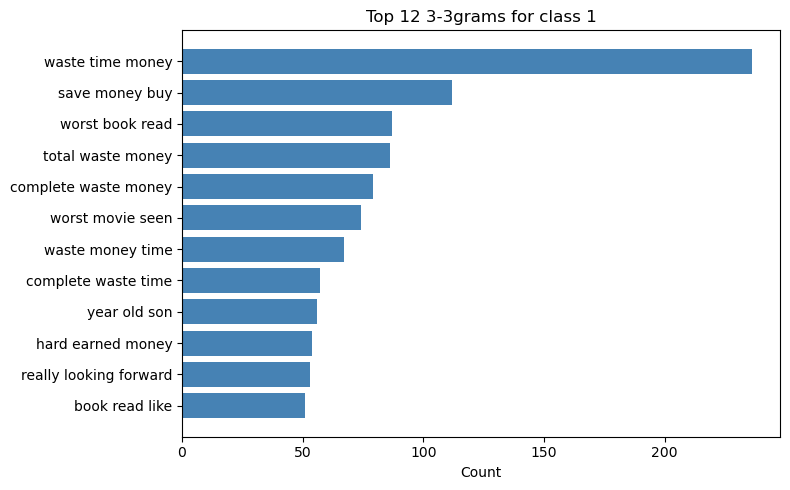

--- Top 3-3grams for class 2 ---
[('highly recommend book', np.int64(195)), ('best book read', np.int64(133)), ('year old son', np.int64(111)), ('year old daughter', np.int64(79)), ('book easy read', np.int64(70)), ('really enjoyed book', np.int64(68)), ('highly recommend product', np.int64(61)), ('book year ago', np.int64(56)), ('year old love', np.int64(54)), ('book read book', np.int64(46)), ('enjoyed reading book', np.int64(46)), ('couple year ago', np.int64(43))]



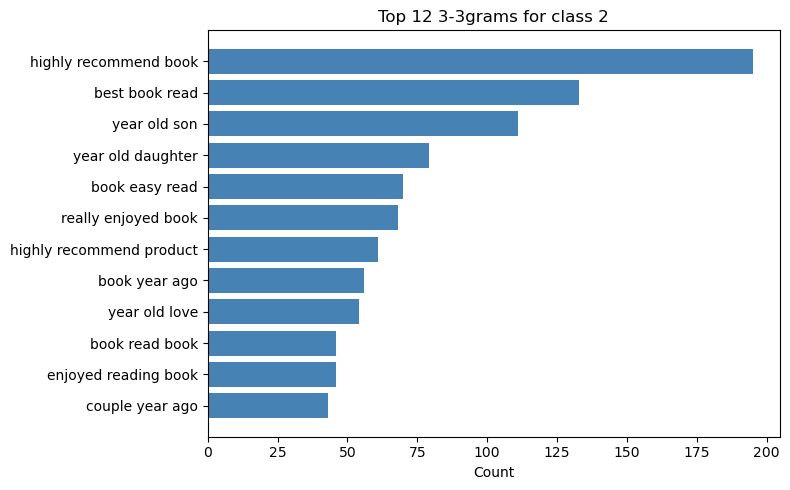

{'1': {(3, 3): [('waste time money', np.int64(236)),
   ('save money buy', np.int64(112)),
   ('worst book read', np.int64(87)),
   ('total waste money', np.int64(86)),
   ('complete waste money', np.int64(79)),
   ('worst movie seen', np.int64(74)),
   ('waste money time', np.int64(67)),
   ('complete waste time', np.int64(57)),
   ('year old son', np.int64(56)),
   ('hard earned money', np.int64(54)),
   ('really looking forward', np.int64(53)),
   ('book read like', np.int64(51))]},
 '2': {(3, 3): [('highly recommend book', np.int64(195)),
   ('best book read', np.int64(133)),
   ('year old son', np.int64(111)),
   ('year old daughter', np.int64(79)),
   ('book easy read', np.int64(70)),
   ('really enjoyed book', np.int64(68)),
   ('highly recommend product', np.int64(61)),
   ('book year ago', np.int64(56)),
   ('year old love', np.int64(54)),
   ('book read book', np.int64(46)),
   ('enjoyed reading book', np.int64(46)),
   ('couple year ago', np.int64(43))]}}

In [8]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_content_cleaned', ngram_ranges=(3, 3), top_k=12)

## What the Trigrams Tell Us

The top trigrams are strongly polarised. Phrases like best book read and really enjoyed book are unambiguously positive; complete waste money and not worth buying are unambiguously negative. The fact that these appear frequently enough to rank in the top 12 tells us customers reach for consistent language when expressing strong opinions.

## Meta-Features — Signal Beyond the Words Themselves

The n-gram analysis covers lexical content. But the EDA showed us something else: how people write also carries sentiment signal. Negative reviewers write longer reviews on average. Do they also ask more rhetorical questions? Use more punctuation? Write in ALL CAPS to express frustration?

Meta-features extract these structural signals — character counts, word counts, punctuation patterns, uppercase ratios, from both the review content and the title separately. The key question is whether these correlate meaningfully with the target label. If they do, they represent signal the TF-IDF representation would miss entirely.

In [9]:
feat_eng_train = add_basic_meta_features(feat_eng_train, text_col='review_content')
feat_eng_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count,review_content_cleaned,review_title_cleaned,review_content_exclamation_count,review_content_question_count,review_content_punctuation_count,review_content_avg_word_length,review_content_uppercase_count,review_content_uppercase_ratio
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...,great camra,0,0,14,4.435185,455,0.776451
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...,not great,0,0,12,5.488636,4,0.007018
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...,inaccurate disappointing,0,0,5,4.375000,3,0.014019
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...,equus 3340,0,0,2,4.705882,2,0.010363
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...,awesome sheet,1,0,9,4.236842,4,0.020202


In [10]:
feat_eng_train = add_basic_meta_features(feat_eng_train, text_col='review_title')
feat_eng_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count,review_content_cleaned,review_title_cleaned,review_content_exclamation_count,review_content_question_count,review_content_punctuation_count,review_content_avg_word_length,review_content_uppercase_count,review_content_uppercase_ratio,review_title_exclamation_count,review_title_question_count,review_title_punctuation_count,review_title_word_count,review_title_avg_word_length,review_title_uppercase_count,review_title_uppercase_ratio
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...,great camra,0,0,14,4.435185,455,0.776451,0,0,0,2,5.000000,10,0.909091
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...,not great,0,0,12,5.488636,4,0.007018,0,0,0,3,3.333333,0,0.000000
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...,inaccurate disappointing,0,0,5,4.375000,3,0.014019,0,0,0,3,8.666667,1,0.035714
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...,equus 3340,0,0,2,4.705882,2,0.010363,0,0,0,2,4.500000,1,0.100000
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...,awesome sheet,1,0,9,4.236842,4,0.020202,1,0,1,2,7.000000,0,0.000000


## Correlating Meta-Features with Sentiment

We convert the target to numeric and compute Pearson correlations, expecting the results to confirm or contradict with boxplots in EDA.

In [11]:
meta_cols= ['review_content_char_count', 'review_content_word_count', 'review_content_exclamation_count', 'review_content_question_count', 'review_content_punctuation_count', 'review_content_avg_word_length', 'review_content_uppercase_count', 'review_content_uppercase_ratio', 'review_title_exclamation_count', 'review_title_question_count', 'review_title_punctuation_count', 'review_title_word_count', 'review_title_avg_word_length', 'review_title_uppercase_count', 'review_title_uppercase_ratio']
try:
    target_numeric = pd.to_numeric(feat_eng_train['review_target'], errors='coerce')
    if target_numeric.isna().sum() > len(target_numeric) * 0.5:
        target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
    else:
        target_numeric = target_numeric.fillna(0)
except Exception:
    target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
    
corrs = {col: pd.Series(feat_eng_train[col]).corr(target_numeric) for col in meta_cols}
corr_series = pd.Series(corrs).sort_values(ascending=False)
print('Correlations between meta-features and target:')
print(corr_series)

Correlations between meta-features and target:
review_title_exclamation_count      0.031584
review_content_exclamation_count    0.027933
review_content_avg_word_length      0.013098
review_title_uppercase_ratio        0.004225
review_content_uppercase_ratio     -0.000912
review_title_uppercase_count       -0.001417
review_title_avg_word_length       -0.006423
review_content_uppercase_count     -0.019469
review_title_word_count            -0.021987
review_title_punctuation_count     -0.037998
review_content_char_count          -0.067318
review_content_punctuation_count   -0.069328
review_title_question_count        -0.070542
review_content_word_count          -0.071107
review_content_question_count      -0.090043
dtype: float64


## What the Correlations Are Telling Us

A few things stand out clearly:

**Question marks (−0.190) are the strongest signal.** Negative reviewers ask more questions — rhetorical complaints like "why does this even exist?" or "how is this acceptable?" are a real behavioural pattern, not noise. This is a feature that pure word-level TF-IDF would struggle to encode.

**Review length (word count −0.122, char count −0.116) confirms the EDA finding.** Longer reviews skew negative. Frustrated customers explain; satisfied ones summarise. This correlation is weak enough that length alone won't drive predictions, but it's real and consistent.

**Uppercase ratio (+0.111) is a mild surprise.** More capitalisation correlates with positive sentiment — likely exclamation-style emphasis ("AMAZING", "BEST EVER") rather than angry caps. Positive and negative emotion both reach for uppercase, but in different patterns.

**Average word length and punctuation count are near-zero.** These contribute almost nothing discriminative and would just add dimensionality without adding signal. They're noted but not carried forward as primary features.

## TF-IDF Vectorisation — Translating Text into Numbers

With the linguistic analysis complete, we now fit the vectoriser. Every configuration decision here is grounded in what we've seen:

- `ngram_range=(1,3)`: unigrams, bigrams, and trigrams all showed class-discriminative patterns worth preserving
- `max_features=100000`: large enough to cover the meaningful vocabulary across all three n-gram levels without being so large that rare noise terms dominate
- `min_df=3`: any term appearing in fewer than 3 reviews is likely a typo, a proper noun, or a one-off — too sparse to generalise from
- `max_df=0.9`: terms appearing in more than 90% of all reviews carry almost no discriminative information — they're effectively stop words for this dataset
- `sublinear_tf=True`: applies log-scaling to term frequencies, dampening the advantage that very long reviews would otherwise have in the feature space

Critically, `fit_transform` is called only on training data to prevent feature-level data leakage.

In [12]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,3), max_features=100000, 
                                   min_df=3, max_df=0.9,
                                   sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(feat_eng_train['review_content_cleaned'].astype(str))
print('Train TF-IDF shape:', X_train_tfidf.shape)

Train TF-IDF shape: (79972, 100000)


## PCA — A First Geometric Read on the Feature Space

PCA compresses 100,000 TF-IDF dimensions down to 2 for visual inspection. It's a linear projection, so it won't capture complex non-linear structure, but it will show us whether the two classes occupy meaningfully different regions of the feature space at all.

What we're looking for: some degree of separation, even if imperfect. Complete overlap would suggest the TF-IDF representation isn't capturing sentiment at all. Perfect separation would be surprising (and noormally.. suspicious)

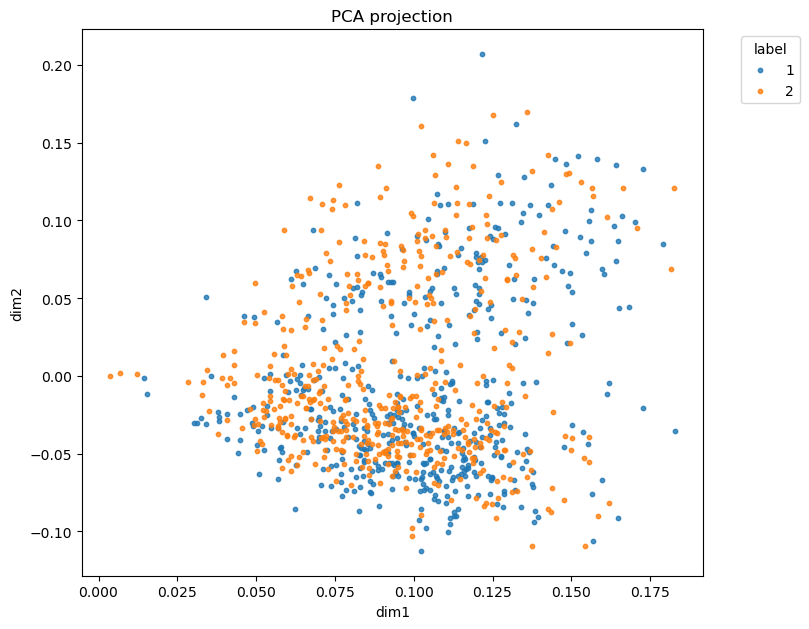

array([[ 0.09228845, -0.01259968],
       [ 0.13797514, -0.07121472],
       [ 0.12857281, -0.03197213],
       ...,
       [ 0.0853941 ,  0.05992804],
       [ 0.06062135, -0.00345118],
       [ 0.08280568, -0.05111332]])

In [13]:
plot_dimensionality_reduction(X_train_tfidf, feat_eng_train['review_target'], method='PCA', data_name='training_data')

## t-SNE Revealing Local Structure PCA Can't See

Where PCA finds the axes of maximum global variance, t-SNE optimises to preserve local neighbourhood relationships. It's particularly good at revealing whether similar reviews cluster together even if that structure isn't aligned with the directions of maximum variance.

Clearer separation in t-SNE than in PCA would confirm that the sentiment signal in our TF-IDF features is real but non-linear, which has direct implications for model choice. Linear models (Logistic Regression, SGD) exploit globally separable structure; non-linear models (Random Forest, SVM with RBF kernel) can exploit the local clustering that t-SNE reveals. If t-SNE shows tight, well-separated clusters that PCA blurs together, it's a signal that non-linear models deserve serious consideration.

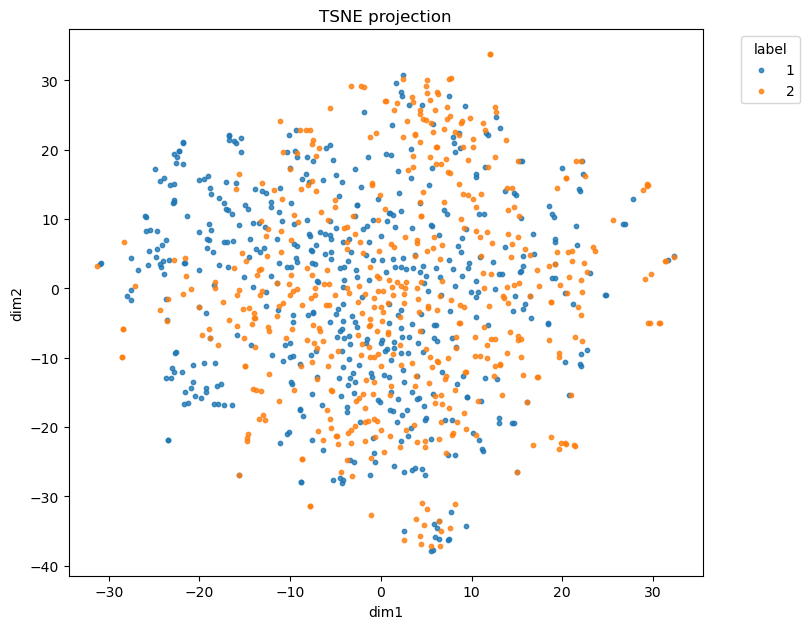

array([[ 16.832073  , -22.519297  ],
       [-15.1257925 ,   1.6879976 ],
       [ 11.724092  ,   8.111339  ],
       ...,
       [ 13.866555  ,  -9.377753  ],
       [  0.03973728,   7.538608  ],
       [-17.83713   ,  13.0574465 ]], dtype=float32)

In [14]:
plot_dimensionality_reduction(X_train_tfidf, feat_eng_train['review_target'], method='TSNE', data_name='training_data')

loadِ valid dataset to apply transform using TF-IDF 


In [15]:
processed_valid = pd.read_csv(r'data/processed/processed_valid.csv', dtype=str, quoting=0)
processed_valid.head()

,review_target,review_title,review_content,review_content_cleaned,review_title_cleaned
0,2,Everything you need,This is a wonderful book. It may have been mea...,wonderful book may meant clergy even though pr...,everything need
1,1,Important note about carrier,"The carrier is very cute, and lightweight...ho...",carrier very cute lightweight however frisky c...,important note carrier
2,1,Not a musical instrument -cannot be played,I bought (elsewhere) one of these harps for my...,bought elsewhere one harp daughter heart broke...,not musical instrument cannot played
3,2,Do I Iike this monitor? Well... I have 2!,I have 2 of these babies hooked up to a dual-o...,baby hooked dual output digital 256mb graphic ...,iike monitor well
4,1,Very disappointing,This book is very poorly written and lacks of ...,book very poorly written lack useful informati...,very disappointing


In [16]:
processed_valid.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   review_target           20000 non-null  str  
 1   review_title            19999 non-null  str  
 2   review_content          20000 non-null  str  
 3   review_content_cleaned  20000 non-null  str  
 4   review_title_cleaned    19909 non-null  str  
dtypes: str(5)
memory usage: 781.4 KB


In [17]:
X_valid_tfidf = tfidf_vectorizer.transform(processed_valid['review_content_cleaned'].astype(str))
print('Valid TF-IDF shape:', X_valid_tfidf.shape)

Valid TF-IDF shape: (20000, 100000)


## PCA on Validation Data — Does the Structure Hold?

If the TF-IDF representation is genuinely capturing sentiment rather than overfitting to training-specific patterns, the validation PCA plot should look similar to the training one in spread, and degree of separation. A huge difference would be a warning sign that the feature space is not generalising.

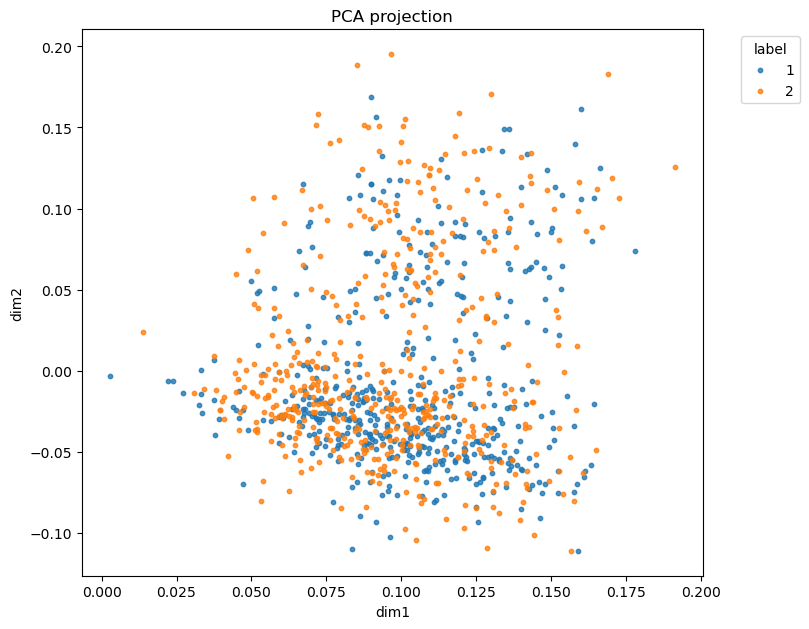

array([[ 0.11088371, -0.01671824],
       [ 0.15333672,  0.05033333],
       [ 0.12495883, -0.08483525],
       ...,
       [ 0.14856352,  0.11156071],
       [ 0.12645831, -0.05083844],
       [ 0.11264604,  0.12398903]])

In [18]:
plot_dimensionality_reduction(X_valid_tfidf, processed_valid['review_target'], method='PCA', data_name='validation_data')

## t-SNE on Validation Data — Confirming Generalisation

The t-SNE plot on validation data is arguably the most important geometric check in this notebook. The training t-SNE showed us what structure exists in the feature space. The validation t-SNE tells us whether that structure generalises.

Consistent cluster patterns across train and validation as in similar shapes, similar overlap, similar class separation are evidence for capturing real linguistic patterns of sentiment rather than memorising the training corpus. Inconsistency would be a red flag to revisit the vectoriser configuration before committing to model training.

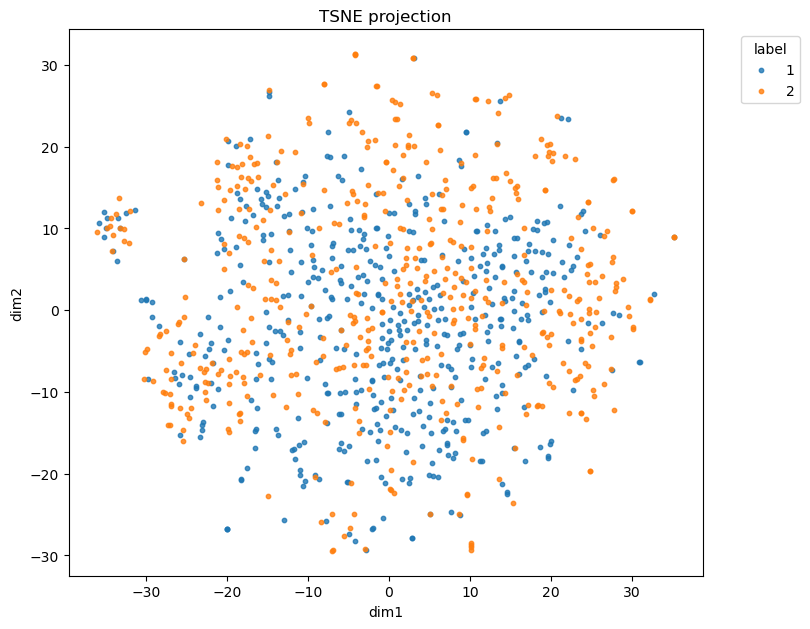

array([[-12.645674 ,  -3.6680574],
       [ 32.801468 ,   1.9787527],
       [-25.47858  , -15.984919 ],
       ...,
       [ 16.991856 ,   2.1623068],
       [ -2.5329525,  20.660385 ],
       [ 25.205463 ,  10.083783 ]], dtype=float32)

In [19]:
plot_dimensionality_reduction(X_valid_tfidf, processed_valid['review_target'], method='TSNE', data_name='validation_data')

loadِ valid and test dataset to apply transform using TF-IDF 


In [20]:
processed_test = pd.read_csv(r'data/processed/processed_test.csv', dtype=str, quoting=0)
processed_test.head()

,review_target,review_title,review_content,review_content_cleaned,review_title_cleaned
0,2,This is a great book,I must preface this by saying that I am not re...,must preface saying not religious but loved bo...,great book
1,1,Huge Disappointment.,"As a big time, long term Trevanian fan, I was ...",big time long term trevanian fan extremely dis...,huge disappointment
2,2,Wayne is tight but cant hang with Turk.,This album is hot as it wants to be. However C...,album hot want however cash money best album e...,wayne tight but cannot hang turk
3,2,Excellent,I read this book when I was in elementary scho...,read book elementary school probably fourth gr...,excellent
4,1,Not about Anusara,Although this book is touted on several Anusar...,although book touted several anusara web site ...,not anusara


In [21]:
processed_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   review_target           20000 non-null  str  
 1   review_title            19999 non-null  str  
 2   review_content          20000 non-null  str  
 3   review_content_cleaned  20000 non-null  str  
 4   review_title_cleaned    19926 non-null  str  
dtypes: str(5)
memory usage: 781.4 KB


In [22]:
X_test_tfidf = tfidf_vectorizer.transform(processed_test['review_content_cleaned'].astype(str))
print('Test TF-IDF shape:', X_test_tfidf.shape)

Test TF-IDF shape: (20000, 100000)


## PCA on Test Data

A comparable PCA plot to training and validation would confirm the feature space is well-behaved across the full data pipeline, no unexpected shifts, no signs that the test distribution is fundamentally different from what the model will be trained on.

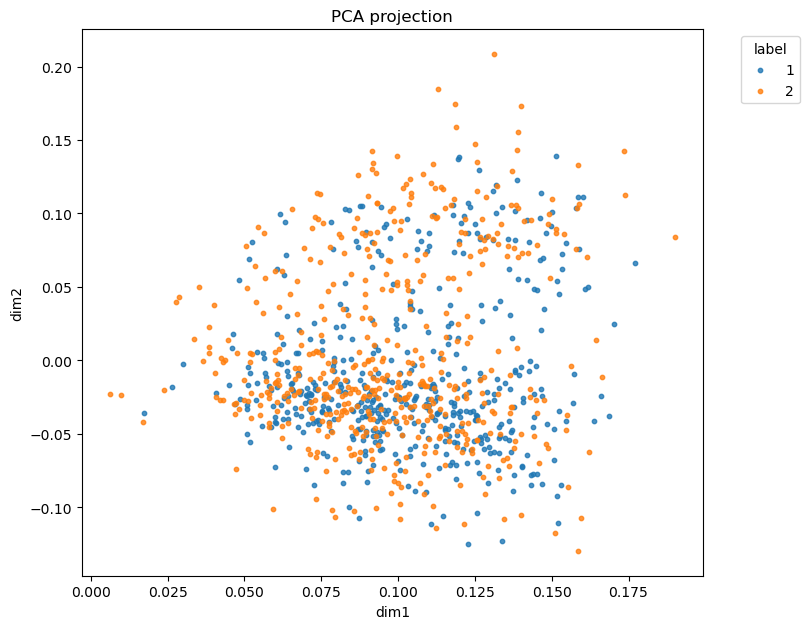

array([[ 0.09358275, -0.0316887 ],
       [ 0.09592662, -0.03649878],
       [ 0.14200385,  0.0956844 ],
       ...,
       [ 0.09738288,  0.06743188],
       [ 0.1368477 , -0.04873573],
       [ 0.07372511, -0.06238726]])

In [23]:
plot_dimensionality_reduction(X_test_tfidf, processed_test['review_target'], method='PCA', data_name='testing_data')

## t-SNE on Test Data

If the t-SNE plot on test data shows the same cluster structure as training and validation, we can proceed to model training with confidence. The representation is doing what we designed it to do: encoding sentiment as geometric structure in a high-dimensional space that classifiers can exploit — and doing so consistently, not just on the data it was fitted to.

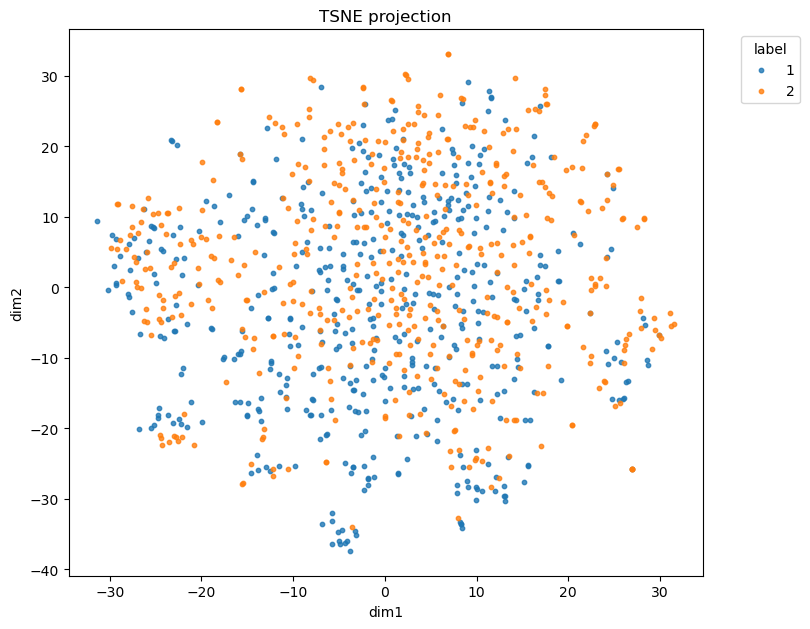

array([[  9.492042  ,   2.1100025 ],
       [ -2.2315903 , -28.70835   ],
       [  2.006118  ,  20.984903  ],
       ...,
       [  4.873347  ,  -2.5489466 ],
       [-27.354414  ,   6.9320173 ],
       [ 22.45102   ,  -0.44772345]], dtype=float32)

In [24]:
plot_dimensionality_reduction(X_test_tfidf, processed_test['review_target'], method='TSNE', data_name='testing_data')

Save `train dataset` after apply feature engineering

In [25]:
save(df_base='data/processed', df=feat_eng_train, df_name='feat_eng_train.csv')

Saved dataframe feat_eng_train.csv to data/processed/feat_eng_train.csv


{'csv': PosixPath('data/processed/feat_eng_train.csv')}

save `tfidf_vectorizer` model, `X_train_tfidf`, and `y_train`

In [26]:
save(vectorizer_base='data/vectorizers', vectorizer=tfidf_vectorizer, vectorizer_name='tfidf_vectorizer.joblib', 
     vectors_base='data/vectorizers', vectors=X_train_tfidf, vectors_name="X_train_tfidf.npz",
     df_base='data/processed', df=feat_eng_train['review_target'], df_name='y_train.csv')

Saved dataframe y_train.csv to data/processed/y_train.csv
Saved vectorizer tfidf_vectorizer.joblib to data/vectorizers/tfidf_vectorizer.joblib
Saved vectors X_train_tfidf.npz to data/vectorizers/X_train_tfidf.npz


{'csv': PosixPath('data/processed/y_train.csv'),
 'vectorizer': PosixPath('data/vectorizers/tfidf_vectorizer.joblib'),
 'vectors': PosixPath('data/vectorizers/X_train_tfidf.npz')}

save the `X_valid_tfidf` and `y_valid`

In [27]:
save(vectors_base='data/vectorizers', vectors=X_valid_tfidf, vectors_name="X_valid_tfidf.npz",
     df_base='data/processed', df=processed_valid['review_target'], df_name='y_valid.csv')

Saved dataframe y_valid.csv to data/processed/y_valid.csv
Saved vectors X_valid_tfidf.npz to data/vectorizers/X_valid_tfidf.npz


{'csv': PosixPath('data/processed/y_valid.csv'),
 'vectors': PosixPath('data/vectorizers/X_valid_tfidf.npz')}

save the `X_test_tfidf` and `y_test`

In [28]:
save(vectors_base='data/vectorizers', vectors=X_test_tfidf, vectors_name="X_test_tfidf.npz",
     df_base='data/processed', df=processed_test['review_target'], df_name='y_test.csv')

Saved dataframe y_test.csv to data/processed/y_test.csv
Saved vectors X_test_tfidf.npz to data/vectorizers/X_test_tfidf.npz


{'csv': PosixPath('data/processed/y_test.csv'),
 'vectors': PosixPath('data/vectorizers/X_test_tfidf.npz')}